In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
#1 Chargement des données
df = pd.read_csv("/kaggle/input/datasets/benjamincaron1/airbnb-berlin/listings.csv")
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,3176,Fabulous Flat in great Location,3718,Britta,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,105.0,63,150,2025-08-09,0.76,1,140,2,First name and Last name: Nicolas Krotz <br/> ...
1,9991,Geourgeous flat - outstanding views,33852,Philipp,Pankow,Prenzlauer Berg Südwest,52.53269,13.41805,Entire home/apt,135.0,6,7,2020-01-04,0.06,1,241,0,03/Z/RA/003410-18
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,Pankow,Prenzlauer Berg Nordwest,52.54813,13.40366,Entire home/apt,75.0,150,26,2023-11-30,0.14,4,168,0,NaN
3,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,Neukölln,Reuterstraße,52.49419,13.42166,Entire home/apt,32.0,93,298,2025-09-02,1.57,1,72,1,NaN
4,20858,Designer Loft in Berlin Mitte,71331,Marc,Pankow,Prenzlauer Berg Südwest,52.53711,13.40888,Entire home/apt,202.0,3,140,2025-07-16,0.89,1,253,4,03/Z/RA/009767-24


In [3]:
#2 Exploration initiale
df.shape

(14274, 18)

In [4]:
df.info

<bound method DataFrame.info of                         id                                               name  \
0                     3176                    Fabulous Flat in great Location   
1                     9991                Geourgeous flat - outstanding views   
2                    14325                Studio Apartment in Prenzlauer Berg   
3                    17904      Beautiful Kreuzberg studio - 3 months minimum   
4                    20858                      Designer Loft in Berlin Mitte   
...                    ...                                                ...   
14269  1515762441083891582                 Cozy 2-Bedroom Apartment in Pankow   
14270  1515762449478095365          Beautiful 1-Bedroom Apartment in Neukölln   
14271  1515796546337797524                       Tasteful Studio in Kreuzberg   
14272  1515901877338207449  Large bright room with balcony in historic Rix...   
14273  1516054633356759428       Zimmer in wunderschöner 110m2 Altbau-Wohnung

In [5]:
#3 Nettoyage
df.isna().sum()

id                                   0
name                                 0
host_id                              0
host_name                           14
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             5010
minimum_nights                       0
number_of_reviews                    0
last_review                       3314
reviews_per_month                 3314
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           4977
dtype: int64

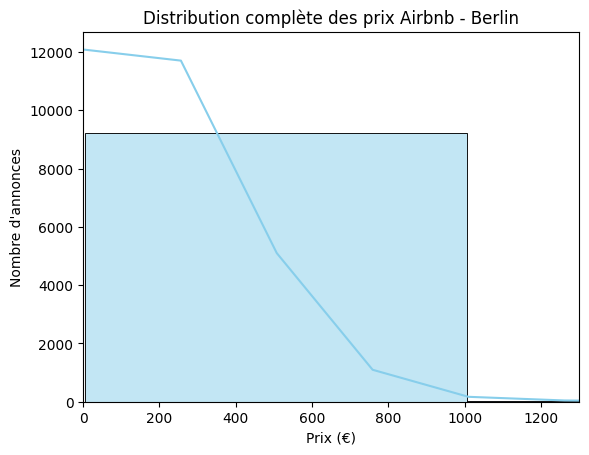

In [6]:
sns.histplot(df["price"], bins=50, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution complète des prix Airbnb - Berlin")
plt.xlabel("Prix (€)")
plt.ylabel("Nombre d'annonces")
plt.xlim(0,1300)
plt.show()

In [7]:
cols = [
    "latitude", "longitude",
    "neighbourhood_group", "neighbourhood",
    "room_type",
    "minimum_nights", "number_of_reviews",
    "reviews_per_month", "availability_365",
    "calculated_host_listings_count"
]

df_clean = df[cols + ["price"]].copy()
df_clean = df_clean.drop(columns=["neighbourhood"]) #object

In [8]:
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

In [9]:
#4 Encodage
df_clean = pd.get_dummies(df_clean, columns=["neighbourhood_group", "room_type"], drop_first=True)

In [10]:
df_clean = df_clean.dropna(subset=["price"])

In [11]:
q99 = df["price"].quantile(0.99)

In [12]:
df_clean = df_clean[df_clean["price"].between(20, q99)]

In [13]:
#5 Split train/test
X = df_clean.drop("price", axis=1)
y = df_clean["price"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
#6 Baseline
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

LinearRegression()

In [17]:
#7 Modèle principal
model_rf = RandomForestRegressor(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [18]:
#Résultats
preds_lr = model_lr.predict(X_test_scaled)
preds_rf = model_rf.predict(X_test)

mae_lr = mean_absolute_error(y_test, preds_lr)
mae_rf = mean_absolute_error(y_test, preds_rf)

# MSE
mse_lr = mean_squared_error(y_test, preds_lr)
mse_rf = mean_squared_error(y_test, preds_rf)

# RMSE
rmse_lr = mse_lr ** 0.5
rmse_rf = mse_rf ** 0.5

summary = pd.DataFrame({
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf]
}, index=["Linear Regression", "Random Forest"])

summary


,MAE,RMSE
Linear Regression,48.175314,69.313896
Random Forest,39.842668,59.902029


In [19]:
#Prédiction personnalisée (simulateur de prix Airbnb)
def build_apartment_df(d, training_cols):
    df_new = pd.DataFrame([d]).copy()

    #même transformation qu'au dataset
    df_new["reviews_per_month"] = df_new.get("reviews_per_month", 0)

    #dummies
    df_new = pd.get_dummies(
        df_new,
        columns=["neighbourhood_group", "room_type"],
        drop_first=True)
    
    # réaligner les colonnes pour correspondre à X_train
    df_new = df_new.reindex(columns=training_cols, fill_value=0)
    return df_new

apartment = {
    "latitude": 52.5200,
    "longitude": 13.4050,
    "neighbourhood_group": "Mitte",
    "room_type": "Entire home/apt",
    "minimum_nights": 3,
    "number_of_reviews": 45,
    "reviews_per_month": 1.2,
    "availability_365": 220,
    "calculated_host_listings_count": 1}

X_cols = list(X_train.columns)
df_ap = build_apartment_df(apartment, X_cols)

#Prédiction
pred_price = model_rf.predict(df_ap)[0]
print(f"Prix : {pred_price:.2f} € / nuit")


Prix : 186.72 € / nuit
